## Part I. Catalog Data Exploration and Preparation

### Goal
Before training machine learning models, we perform an exploratory analysis of the photometric features derived from the Rubin DP1 catalog. This notebook explores the Vera C. Rubin Observatory Data Preview 1 (DP1) catalog and prepares the photometric features required for subsequent photometric redshift analysis.

### Metodology
1. Explore the contents and structure of the Rubin DP1 object catalog.  
2. Convert photometric fluxes into magnitudes.  
3. Correct photometry for Galactic reddening/extinction.  
4. Derive color features from corrected magnitudes.  
5. Create magnitudes and color histograms, as well as color-color diagrams.


##### We import packages we will need

In [4]:
import tables_io                    # For reading hdf5 files
import numpy as np                  
import matplotlib.pyplot as plt
from pathlib import Path            
from photoz_utils import *

##### Set the working directory to the project root directory

In [5]:
pz_dir = Path.cwd().parent

##### Read the data

In [16]:
data = tables_io.read(f'{pz_dir}/data/object.hdf5')
print(data.keys())

odict_keys(['coord_dec', 'coord_decErr', 'coord_ra', 'coord_raErr', 'coord_ra_dec_Cov', 'deblend_failed', 'deblend_incompleteData', 'deblend_isolatedParent', 'deblend_iterations', 'deblend_logL', 'deblend_masked', 'deblend_nChild', 'deblend_nPeaks', 'deblend_parentTooBig', 'deblend_peak_center_x', 'deblend_peak_center_y', 'deblend_skipped', 'deblend_tooManyPeaks', 'detect_fromBlend', 'detect_isDeblendedModelSource', 'detect_isIsolated', 'ebv', 'footprintArea', 'g_ap03Flux', 'g_ap03FluxErr', 'g_ap03Flux_flag', 'g_ap06Flux', 'g_ap06FluxErr', 'g_ap06Flux_flag', 'g_ap09Flux', 'g_ap09FluxErr', 'g_ap09Flux_flag', 'g_ap12Flux', 'g_ap12FluxErr', 'g_ap12Flux_flag', 'g_ap17Flux', 'g_ap17FluxErr', 'g_ap17Flux_flag', 'g_ap25Flux', 'g_ap25FluxErr', 'g_ap25Flux_flag', 'g_ap35Flux', 'g_ap35FluxErr', 'g_ap35Flux_flag', 'g_ap50Flux', 'g_ap50FluxErr', 'g_ap50Flux_flag', 'g_ap70Flux', 'g_ap70FluxErr', 'g_ap70Flux_flag', 'g_apFlux_flag', 'g_apFlux_flag_apertureTruncated', 'g_apFlux_flag_sincCoeffsTruncate

##### We print out all the names of the arrays

In [7]:
print(data.keys())
print(type(data))

odict_keys(['coord_dec', 'coord_decErr', 'coord_ra', 'coord_raErr', 'coord_ra_dec_Cov', 'deblend_failed', 'deblend_incompleteData', 'deblend_isolatedParent', 'deblend_iterations', 'deblend_logL', 'deblend_masked', 'deblend_nChild', 'deblend_nPeaks', 'deblend_parentTooBig', 'deblend_peak_center_x', 'deblend_peak_center_y', 'deblend_skipped', 'deblend_tooManyPeaks', 'detect_fromBlend', 'detect_isDeblendedModelSource', 'detect_isIsolated', 'ebv', 'footprintArea', 'g_ap03Flux', 'g_ap03FluxErr', 'g_ap03Flux_flag', 'g_ap06Flux', 'g_ap06FluxErr', 'g_ap06Flux_flag', 'g_ap09Flux', 'g_ap09FluxErr', 'g_ap09Flux_flag', 'g_ap12Flux', 'g_ap12FluxErr', 'g_ap12Flux_flag', 'g_ap17Flux', 'g_ap17FluxErr', 'g_ap17Flux_flag', 'g_ap25Flux', 'g_ap25FluxErr', 'g_ap25Flux_flag', 'g_ap35Flux', 'g_ap35FluxErr', 'g_ap35Flux_flag', 'g_ap50Flux', 'g_ap50FluxErr', 'g_ap50Flux_flag', 'g_ap70Flux', 'g_ap70FluxErr', 'g_ap70Flux_flag', 'g_apFlux_flag', 'g_apFlux_flag_apertureTruncated', 'g_apFlux_flag_sincCoeffsTruncate

That is a large number of columns. You can find a detailed description of all available fields in the official DP1 schema documentation:

https://sdm-schemas.lsst.io/dp1.html#Object

#### Dataset

This project uses data from the Vera C. Rubin Observatory Data Preview 1 (DP1), a large-scale astronomical catalog containing multi-band photometric observations of celestial objects.

The Data Preview 1 (DP1) catalog provides five different types of flux measurements:

- {band}_psfFlux
- {band}_gaap1p0Flux
- {band}_gaap3p0Flux
- {band}_cModelFlux
- {band}_sersicFlux

These measurements are available across the six optical bands (`u`, `g`, `r`, `i`, `z`, `y`) and are used to construct photometric features for photometric redshift estimation.

> Due to Rubin Observatory data-access restrictions, the raw data are not redistributed in this repository.

##### Inspect the total number of observations in the dataset
(The number of observations available is: 83989) 

In [8]:
for band in 'ugrizy':
    flux = data[f'{band}_psfFlux']

    frac_nan = np.isnan(flux).mean()

    print(
        f'{band}: '
        f'{100*frac_nan:.2f}% NaN'
    )

u: 6.41% NaN
g: 1.28% NaN
r: 2.41% NaN
i: 1.89% NaN
z: 2.51% NaN
y: 9.70% NaN


##### Convert the different flux measurements provided in the dataset into magnitudes using a utility function from the `preprocessing` package

In [9]:
mags_psf = data_preprocessing.make_mag_dict(data, '{band}_psfFlux', 'ugrizy')
mags_cModel = data_preprocessing.make_mag_dict(data, '{band}_cModelFlux', 'ugrizy')
mags_sersic = data_preprocessing.make_mag_dict(data, '{band}_sersicFlux', 'ugrizy')
mags_1p0 = data_preprocessing.make_mag_dict(data, '{band}_gaap1p0Flux', 'ugrizy')
mags_3p0 = data_preprocessing.make_mag_dict(data, '{band}_gaap3p0Flux', 'ugrizy')   

/home/jose/Documentos/photoz-ml/src/photoz_utils/data_preprocessing.py:22: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10(fluxes) + zero_points
/home/jose/Documentos/photoz-ml/src/photoz_utils/data_preprocessing.py:22: RuntimeWarning: divide by zero encountered in log10
  return -2.5 * np.log10(fluxes) + zero_points


#### Reddening Correction

To account for Galactic dust extinction, we apply a reddening correction to the observed magnitudes. For each photometric band, the corrected magnitude is computed as:

$$
m_{\mathrm{corr}} = m - E(B-V)\,R_{\mathrm{band}}
$$

where:

- **`ebv`** ($E(B-V)$) quantifies the amount of dust extinction along a particular line of sight and is <u> provided in the input catalog</u>.
- **`band_e_bv`** ($R_{\mathrm{band}}$) is a band-dependent reddening coefficient, <u>provided in the next cell</u>.

Thus, for each band, we subtract the product $E(B-V)\,R_{\mathrm{band}}$ from the observed magnitude to obtain the reddening-corrected magnitude.


In [10]:
lsst_def_a_env = dict(
    u_lsst=4.81,
    g_lsst=3.64,
    r_lsst=2.70,
    i_lsst=2.06,
    z_lsst=1.58,
    y_lsst=1.31,
)
ebv = data['ebv']
print(ebv)

[0.00960288 0.00973903 0.00998873 ... 0.01032455 0.01036346 0.0101299 ]


In [11]:
mags_redd_psf = data_preprocessing.mags_correct_reddening(mags_psf, ebv, lsst_def_a_env, '{band}_lsst', 'ugrizy')
print(mags_redd_psf)
mags_redd_cModel = data_preprocessing.mags_correct_reddening(mags_cModel, ebv, lsst_def_a_env, '{band}_lsst', 'ugrizy')
mags_redd_1p0 = data_preprocessing.mags_correct_reddening(mags_1p0, ebv, lsst_def_a_env, '{band}_lsst', 'ugrizy')
mags_redd_3p0 = data_preprocessing.mags_correct_reddening(mags_3p0, ebv, lsst_def_a_env, '{band}_lsst', 'ugrizy')
mags_redd_sersic = data_preprocessing.mags_correct_reddening(mags_sersic, ebv, lsst_def_a_env, '{band}_lsst', 'ugrizy')




{'u': array([      nan, 24.475922,       nan, ...,       nan,       nan,
             nan], shape=(83989,), dtype=float32), 'g': array([26.730644, 25.192968,       nan, ..., 24.396425, 24.075718,
       24.40532 ], shape=(83989,), dtype=float32), 'r': array([26.753159, 24.321884, 23.605404, ...,       nan,       nan,
             nan], shape=(83989,), dtype=float32), 'i': array([23.948603,       nan,       nan, ...,       nan,       nan,
             nan], shape=(83989,), dtype=float32), 'z': array([nan, nan, nan, ..., nan, nan, nan], shape=(83989,), dtype=float32), 'y': array([nan, nan, nan, ..., nan, nan, nan], shape=(83989,), dtype=float32)}


#### Converting Corrected Magnitudes into Colors

In [12]:
colors_psf = data_preprocessing.make_color_dict(mags_redd_psf, '{band}', 'ugrizy')
print(colors_psf)
colors_cModel = data_preprocessing.make_color_dict(mags_redd_cModel, '{band}', 'ugrizy')
colors_1p0 = data_preprocessing.make_color_dict(mags_redd_1p0, '{band}', 'ugrizy')
colors_3p0 = data_preprocessing.make_color_dict(mags_redd_3p0, '{band}', 'ugrizy')
colors_sersic = data_preprocessing.make_color_dict(mags_redd_sersic, '{band}', 'ugrizy')


{'u-g': array([       nan, 0.03135109,        nan, ...,        nan,        nan,
              nan], shape=(83989,), dtype=float32), 'g-r': array([ 0.00091362, -0.0382061 ,         nan, ...,         nan,
               nan,         nan], shape=(83989,), dtype=float32), 'r-i': array([-0.12023735,         nan,         nan, ...,         nan,
               nan,         nan], shape=(83989,), dtype=float32), 'i-z': array([nan, nan, nan, ..., nan, nan, nan], shape=(83989,), dtype=float32), 'z-y': array([nan, nan, nan, ..., nan, nan, nan], shape=(83989,), dtype=float32)}


/home/jose/Documentos/photoz-ml/src/photoz_utils/data_preprocessing.py:84: RuntimeWarning: invalid value encountered in subtract
  colors[f"{band_}-{bands[i+1]}"] = mag_a - mag_b


##### Summary

We construct **11 features** from a given flux measurement for each flux type (**remember that there are five different flux types**). These features are:

1. Magnitude in the `u` band  
2. Magnitude in the `g` band  
3. Magnitude in the `r` band  
4. Magnitude in the `i` band  
5. Magnitude in the `z` band  
6. Magnitude in the `y` band  
7. `u - g` color  
8. `g - r` color  
9. `r - i` color  
10. `i - z` color  
11. `z - y` color

We will foucus now with the psf Flux type.

##### We explore the features using histograms of magnitudes and colors, as well as color-color diagrams.

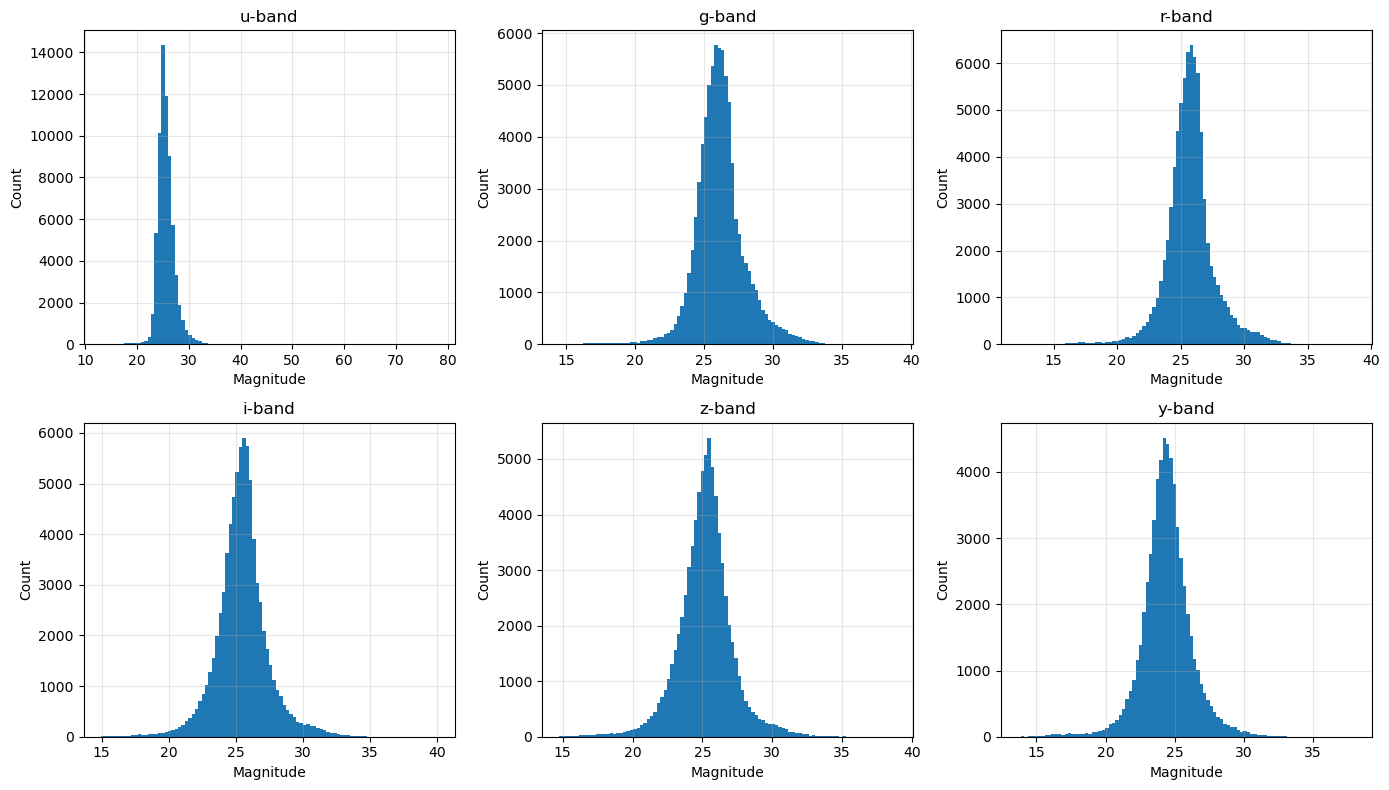

In [13]:
plotting_functions.plot_magnitude_histograms(mags_redd_psf, 'ugrizy', bins=100, figsize=(14, 8))

#### Magnitude Distributions

The histograms of magnitudes in the ugrizy bands provide an overview of the photometric properties of the sample. In general, the distributions peak around magnitudes $\sim 24 - 26$, indicating a larger population of faint objects compared to bright ones, which is expected in deep sky surveys.

Additionally, the asymmetric tails toward larger magnitudes suggest the presence of increasingly faint sources, where photometric uncertainties are expected to grow. Since photometric redshift performance often degrades for faint objects, these distributions may later help interpret model performance as a function of brightness.

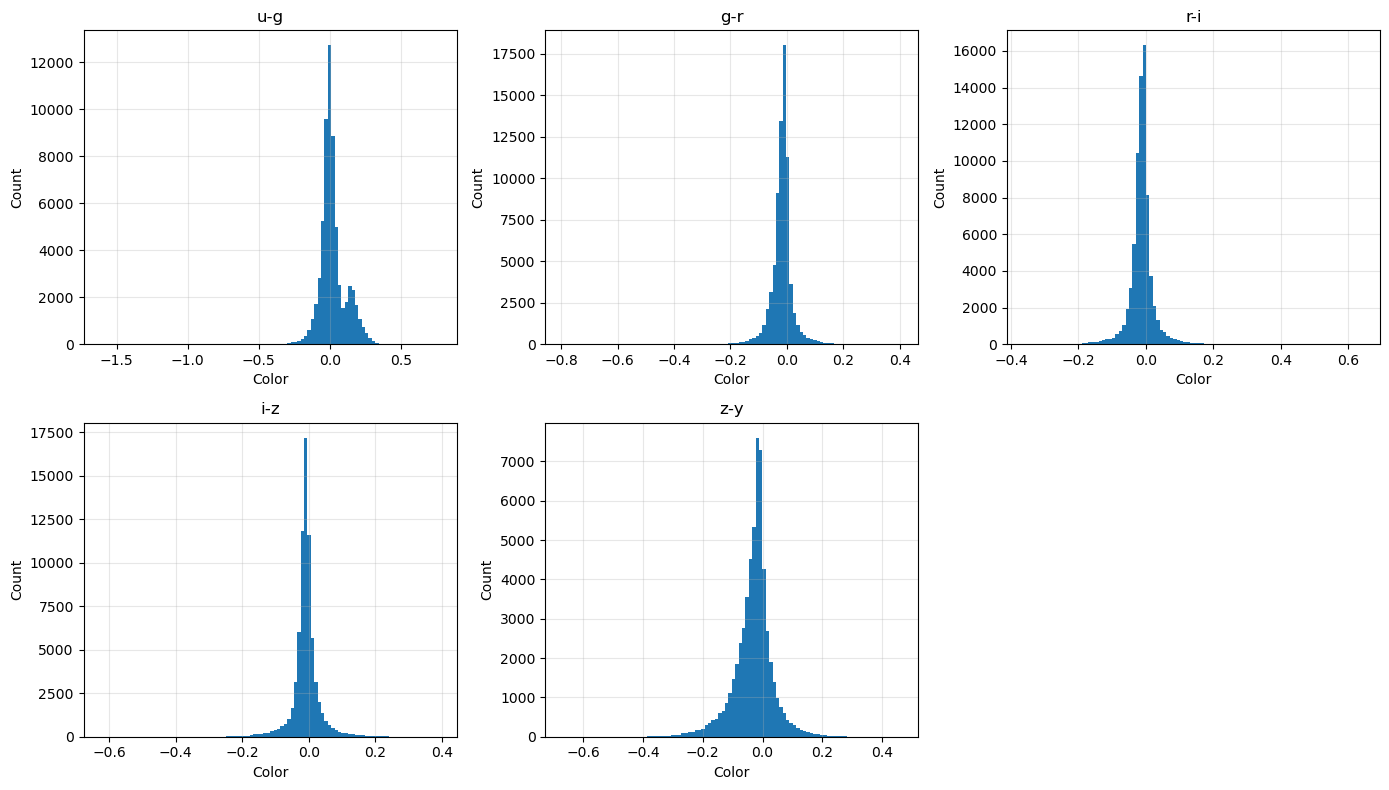

In [14]:
plotting_functions.plot_color_histograms(colors_psf, 'ugrizy', bins=100, figsize=(14, 8))

#### olor Distributions

We construct photometric colors from adjacent bands:

$$
u-g,\quad g-r,\quad r-i,\quad i-z,\quad z-y
$$

Color features are particularly important because they encode spectral information independently of the overall brightness of the object. Since redshift effectively shifts spectral features across photometric bands, colors are expected to be more informative for redshift prediction than magnitudes alone.

The color distributions appear relatively compact and centered around small values, suggesting physically consistent measurements without obvious extreme outliers. Mild asymmetries or substructures may indicate the presence of different source populations or objects at different redshifts.

In [15]:
plotting_functions.plot_color_color_diagrams(colors_psf, 'ugrizy', figsize=(18, 15), point_size=1, alpha=0.3)

for color in colors_psf:
    print(
        color,
        np.nanmin(colors_psf[color]),
        np.nanmax(colors_psf[color])
    )

NameError: name 'combinations' is not defined

#### Color–Color Diagrams

Color–color diagrams are widely used in astronomy to explore correlations between photometric bands and identify structure in the feature space.

The scatter plots reveal clear non-random patterns and correlations between colors, indicating that the photometric features are not independent. Instead, objects occupy restricted regions of color space, likely reflecting differences in source populations and redshift evolution.

This is particularly relevant for machine learning applications, since predictive models can exploit these structured relationships to infer photometric redshifts. The presence of coherent trends in color–color space suggests that the extracted features contain meaningful information for supervised learning.

### Building a New Feature

In addition to individual magnitudes and colors, we can construct an additional feature that summarizes the overall photometric information across the six Rubin bands (`ugrizy`). Indeed we now construct the **train_features** data.

Since magnitudes are logarithmic quantities and therefore cannot be directly added, we first compute the **total flux** by summing the fluxes across all bands:

$$
F_{\mathrm{total}} =
F_u + F_g + F_r + F_i + F_z + F_y
$$

We then convert this quantity into a **total magnitude** using the standard magnitude definition:

$$
m_{\mathrm{total}}
=

-2.5 \log_{10}
\left(
F_{\mathrm{total}}
\right)
+
ZP
$$

where $ZP$ denotes the photometric zero point. This feature is intended to capture the overall brightness of the source and may provide additional information for machine learning models used in photometric redshift estimation.


In [ ]:
train_features = data_preprocessing.prepare_features(data , '{band}_psfFlux', 'ugrizy')

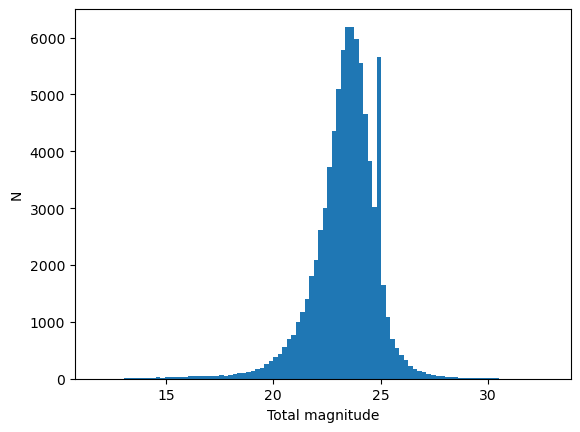

In [ ]:
plt.hist(train_features[:, 0], bins=100)
plt.xlabel("Total magnitude")
plt.ylabel("N")
plt.show()

<p align="center">
    <img src="../images/train_features.png" width="800">
</p>

<p align="center">
    <em>**Figure 1:** Feature set constructed for training the machine learning models.</em>
</p>

## Next Step: Machine Learning Models for Photometric Redshift Estimation

In the next notebook, we will move from exploratory data analysis to the implementation of machine learning models for photometric redshift (photo-z) estimation.

Using the photometric features constructed in this notebook — including magnitudes and colors derived from the ugrizy bands — we will train supervised learning models to predict redshift values from spectroscopic targets.